# Task 1 — Idiom Detection

## Objective
This notebook benchmarks idiom detection as a binary classification task.

## Input / Output
- **Input:** sentence containing an idiom candidate
- **Output:** idiomatic (1) or literal (0)

## Models
This notebook evaluates three models:
1. Logistic Regression (TF-IDF baseline)
2. RoBERTa
3. DeBERTa-v3

In [1]:
# 1. Setup
# =========================================

from pathlib import Path
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

BASE_DIR = Path("..").resolve()
TASK_DIR = BASE_DIR / "deep_learning" / "datasets" / "idiom_detection"
MODELS_DIR = BASE_DIR / "deep_learning" / "models"

print("BASE_DIR :", BASE_DIR)
print("TASK_DIR :", TASK_DIR)
print("Exists   :", TASK_DIR.exists())

BASE_DIR : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
TASK_DIR : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\idiom_detection
Exists   : True


## Load Dataset

We load the preprocessed idiom detection dataset (train / validation / test).

We also verify:
- shapes
- label distribution
- sample rows

In [3]:
# 2. Load dataset
# =========================================

train_path = TASK_DIR / "train.csv"
val_path   = TASK_DIR / "validation.csv"
test_path  = TASK_DIR / "test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)


# Quick label distribution
# =========================================

def show_distribution(df, name):
    counts = df["label"].value_counts()
    print(f"\n{name} distribution:")
    print(counts)
    print("Ratio:", (counts / len(df)).round(3).to_dict())

show_distribution(train_df, "Train")
show_distribution(val_df, "Validation")
show_distribution(test_df, "Test")


# Preview sample
# =========================================

train_df.head(2)

Train shape: (87320, 16)
Val shape  : (10943, 16)
Test shape : (10883, 16)

Train distribution:
label
1    44128
0    43192
Name: count, dtype: int64
Ratio: {1: 0.505, 0: 0.495}

Validation distribution:
label
1    5551
0    5392
Name: count, dtype: int64
Ratio: {1: 0.507, 0: 0.493}

Test distribution:
label
1    5505
0    5378
Name: count, dtype: int64
Ratio: {1: 0.506, 0: 0.494}


,input_text,label,idiom_canonical,idiom_surface,meaning_en,meaning_ar,example_usage_label,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,contains_profanity,example_length,semantic_consistency,canonical_semantic_score
0,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.",1,$100 hamburger,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",idiomatic,ambiguous,semi_opaque,neutral,regional,medium,False,19.0,0.593185,0.762083
1,Pilots often joke about taking a $100 hamburger when planning casual weekend flights.,1,$100 hamburger,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",idiomatic,ambiguous,semi_opaque,neutral,regional,medium,False,13.0,0.387052,0.833575


## Data Exploration

We analyze:
- sentence length distribution
- differences between idiomatic and literal usage
- difficulty and ambiguity signals

This helps understand what makes idiom detection challenging.

Text length stats:
count    87320.000000
mean        78.033646
std         23.659526
min          2.000000
25%         66.000000
50%         78.000000
75%         91.000000
max        623.000000
Name: text_length, dtype: float64


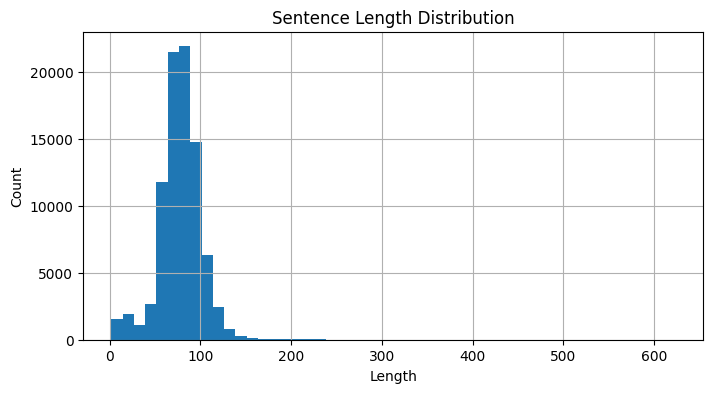

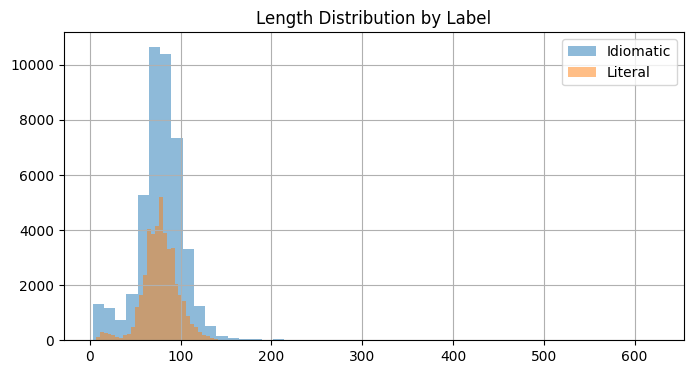


Difficulty distribution:
learner_difficulty
medium    64923
hard      11286
easy      11111
Name: count, dtype: int64

Ambiguity distribution:
ambiguity_flag
semi_literal_possible    56596
strongly_idiomatic       22363
ambiguous                 8361
Name: count, dtype: int64


In [4]:
# 3. Data exploration
# =========================================

import matplotlib.pyplot as plt


# Text length analysis
# =========================================

train_df["text_length"] = train_df["input_text"].str.len()

print("Text length stats:")
print(train_df["text_length"].describe())


# Plot distribution
plt.figure(figsize=(8, 4))
train_df["text_length"].hist(bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


# Length vs label
# =========================================

plt.figure(figsize=(8, 4))

train_df[train_df["label"] == 1]["text_length"].hist(alpha=0.5, bins=50, label="Idiomatic")
train_df[train_df["label"] == 0]["text_length"].hist(alpha=0.5, bins=50, label="Literal")

plt.legend()
plt.title("Length Distribution by Label")
plt.show()


# Difficulty distribution
# =========================================

if "learner_difficulty" in train_df.columns:
    print("\nDifficulty distribution:")
    print(train_df["learner_difficulty"].value_counts())


# Ambiguity analysis
# =========================================

if "ambiguity_flag" in train_df.columns:
    print("\nAmbiguity distribution:")
    print(train_df["ambiguity_flag"].value_counts())

### Sentence Length

    length is NOT a strong discriminative feature
    models must rely on semantic understanding, not heuristics
    
**Idiomatic and literal sentences have very similar length distributions**

    
### Idiomatic vs Literal (Length Overlap)

    Strong overlap between both classes
    
**The task is non-trivial and requires contextual understanding**

### Difficulty Distribution

    Medium: ~65K
    Hard: ~11K
    Easy: ~11K

**Dataset is not biased toward easy cases, making it suitable for robust evaluation**

### Ambiguity

    semi_literal_possible: 56K
    strongly_idiomatic: 22K
    ambiguous: 8K
    
**A large portion of examples contain semi-literal ambiguity, making idiom detection inherently challenging.**


## Baseline Model — Logistic Regression

We train a simple TF-IDF + Logistic Regression model as a baseline.

This provides a reference point for evaluating transformer-based models.

## Model 1 — Logistic Regression Baseline

This baseline uses TF-IDF features with Logistic Regression.
It provides a simple non-transformer reference for the idiom detection task.

In [5]:
import importlib.util

module_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_baseline.py"

spec = importlib.util.spec_from_file_location("baseline_model", module_path)
baseline_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(baseline_module)

baseline_out = baseline_module.train_model()

print("Model dir   :", baseline_out["model_dir"])
print("Metrics CSV :", baseline_out["metrics_path"])
print("Predictions :", baseline_out["predictions_path"])

Vectorizing text with TF-IDF...
Training Logistic Regression model...

Evaluating on validation set...
Validation Accuracy: 0.8418
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      5392
           1       0.84      0.85      0.85      5551

    accuracy                           0.84     10943
   macro avg       0.84      0.84      0.84     10943
weighted avg       0.84      0.84      0.84     10943


Evaluating on test set...
Test Accuracy: 0.8406
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      5378
           1       0.84      0.85      0.84      5505

    accuracy                           0.84     10883
   macro avg       0.84      0.84      0.84     10883
weighted avg       0.84      0.84      0.84     10883

Model dir   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_baseline
Metrics CSV : C:\Users\ayman\Documents\IdiomX\github_

### Results Summary

Results Summary

    Validation Accuracy: 0.8418
    Test Accuracy: 0.8406
    Balanced precision/recall
    No overfitting
    
The TF-IDF + Logistic Regression baseline achieves ~84% accuracy, indicating that lexical features provide a strong signal for idiom detection. However, the performance ceiling suggests the need for contextual models.

## Baseline Tuning — Logistic Regression

We perform a controlled parameter search for the Logistic Regression baseline.

The tuning explores:
- regularization strength (`C`)
- n-gram range
- vocabulary size (`max_features`)
- class weighting

The best configuration is selected using validation F1.

In [7]:
import importlib.util

module_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_baseline_tuned.py"

spec = importlib.util.spec_from_file_location("baseline_tuned_model", module_path)
baseline_tuned_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(baseline_tuned_module)

baseline_tuned_out = baseline_tuned_module.train_model()

print("Model dir          :", baseline_tuned_out["model_dir"])
print("Tuning results CSV :", baseline_tuned_out["tuning_results_path"])
print("Best metrics CSV   :", baseline_tuned_out["best_metrics_path"])
print("Predictions        :", baseline_tuned_out["predictions_path"])

Loading dataset...
Total configs to test: 72

Run 1/72
C=0.5, ngram_range=(1, 1), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8351, 'precision': 0.8343, 'recall': 0.8424, 'f1': 0.8383, 'macro_f1': 0.8351, 'weighted_f1': 0.8351}

Run 2/72
C=0.5, ngram_range=(1, 1), max_features=20000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8355, 'precision': 0.8362, 'recall': 0.8404, 'f1': 0.8383, 'macro_f1': 0.8355, 'weighted_f1': 0.8355}

Run 3/72
C=0.5, ngram_range=(1, 1), max_features=30000, class_weight=None
Validation metrics:
{'accuracy': 0.8351, 'precision': 0.8343, 'recall': 0.8424, 'f1': 0.8383, 'macro_f1': 0.8351, 'weighted_f1': 0.8351}

Run 4/72
C=0.5, ngram_range=(1, 1), max_features=30000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8355, 'precision': 0.8362, 'recall': 0.8404, 'f1': 0.8383, 'macro_f1': 0.8355, 'weighted_f1': 0.8355}

Run 5/72
C=0.5, ngram_range=(1, 1), max_features=50000, class_weight=None
Validation metrics:
{'ac

Validation metrics:
{'accuracy': 0.843, 'precision': 0.8419, 'recall': 0.8501, 'f1': 0.846, 'macro_f1': 0.8429, 'weighted_f1': 0.843}

Run 30/72
C=1.0, ngram_range=(1, 2), max_features=50000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8413, 'precision': 0.8426, 'recall': 0.8449, 'f1': 0.8438, 'macro_f1': 0.8412, 'weighted_f1': 0.8413}

Run 31/72
C=1.0, ngram_range=(1, 3), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8399, 'precision': 0.8364, 'recall': 0.8508, 'f1': 0.8435, 'macro_f1': 0.8398, 'weighted_f1': 0.8399}

Run 32/72
C=1.0, ngram_range=(1, 3), max_features=20000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8412, 'precision': 0.8409, 'recall': 0.8472, 'f1': 0.844, 'macro_f1': 0.8411, 'weighted_f1': 0.8412}

Run 33/72
C=1.0, ngram_range=(1, 3), max_features=30000, class_weight=None
Validation metrics:
{'accuracy': 0.8391, 'precision': 0.8361, 'recall': 0.8492, 'f1': 0.8426, 'macro_f1': 0.839, 'weighted_f1': 0.839}

Run 34/7

Validation metrics:
{'accuracy': 0.8443, 'precision': 0.8445, 'recall': 0.8494, 'f1': 0.847, 'macro_f1': 0.8442, 'weighted_f1': 0.8443}

Run 58/72
C=5.0, ngram_range=(1, 1), max_features=30000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8425, 'precision': 0.8435, 'recall': 0.8467, 'f1': 0.8451, 'macro_f1': 0.8425, 'weighted_f1': 0.8425}

Run 59/72
C=5.0, ngram_range=(1, 1), max_features=50000, class_weight=None
Validation metrics:
{'accuracy': 0.8443, 'precision': 0.8445, 'recall': 0.8494, 'f1': 0.847, 'macro_f1': 0.8442, 'weighted_f1': 0.8443}

Run 60/72
C=5.0, ngram_range=(1, 1), max_features=50000, class_weight=balanced
Validation metrics:
{'accuracy': 0.8425, 'precision': 0.8435, 'recall': 0.8467, 'f1': 0.8451, 'macro_f1': 0.8425, 'weighted_f1': 0.8425}

Run 61/72
C=5.0, ngram_range=(1, 2), max_features=20000, class_weight=None
Validation metrics:
{'accuracy': 0.8421, 'precision': 0.8419, 'recall': 0.848, 'f1': 0.8449, 'macro_f1': 0.842, 'weighted_f1': 0.8421}

Run 62

In [11]:
PROJECT_ROOT = BASE_DIR
DATA_DIR = PROJECT_ROOT / "deep_learning" / "datasets" / "idiom_detection"
MODEL_DIR = PROJECT_ROOT / "deep_learning" / "models" / "idiom_detection_baseline_tuned"

print(DATA_DIR)
print(MODEL_DIR)

C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\idiom_detection
C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_baseline_tuned


In [12]:
best_metrics_df = pd.read_csv(baseline_tuned_out["best_metrics_path"])
display(best_metrics_df)

,run_id,C,ngram_range,max_features,class_weight,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_macro_f1,validation_weighted_f1,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_weighted_f1
0,66,5.0,"(1, 2)",50000,balanced,0.848031,0.851156,0.848856,0.850005,0.848004,0.848033,0.843517,0.841048,0.851589,0.846286,0.843467,0.8435


## Confusion Matrix — Tuned Baseline

This matrix shows how the model distinguishes between idiomatic and literal usage.

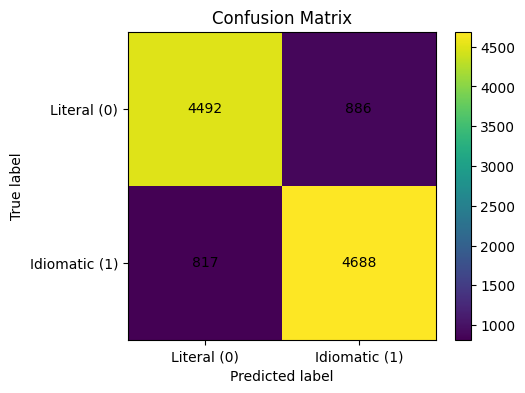

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load predictions
preds_df = pd.read_csv(baseline_tuned_out["predictions_path"])

y_true = preds_df["label"]
y_pred = preds_df["pred"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Literal (0)", "Idiomatic (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

## Confusion Matrix Analysis

The model demonstrates balanced performance across both classes, with similar error rates for literal and idiomatic expressions.

- False Positives (Literal → Idiomatic): 886
- False Negatives (Idiomatic → Literal): 817

This indicates that the model does not exhibit strong bias toward either class, which is expected due to the balanced dataset.

However, a significant number of misclassifications remain, suggesting that surface-level lexical features are insufficient for fully capturing idiomatic meaning.

In [14]:
baseline_metrics = pd.read_csv(baseline_out["metrics_path"])
tuned_metrics = pd.read_csv(baseline_tuned_out["best_metrics_path"])

comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Accuracy": [
        baseline_metrics["test_accuracy"].values[0],
        tuned_metrics["test_accuracy"].values[0]
    ],
    "F1": [
        baseline_metrics["test_f1"].values[0],
        tuned_metrics["test_f1"].values[0]
    ]
})

display(comparison)

,Model,Accuracy,F1
0,Baseline,0.840577,0.844045
1,Tuned,0.843517,0.846286


## Error Analysis

We inspect cases where the model fails to distinguish between idiomatic and literal usage.

These examples highlight the challenges of ambiguity and contextual meaning.

In [15]:
# Wrong predictions
errors = preds_df[preds_df["label"] != preds_df["pred"]]

print("Total errors:", len(errors))

# Show some samples
display(errors[["input_text", "label", "pred"]].head(10))

Total errors: 1703


,input_text,label,pred
11,Many fans collect wands branded with Avada Kedavra as memorabilia.,0,1
16,Benjamin Button's story,0,1
17,play Benjamin Button,0,1
18,Benjamin Button movie,0,1
21,The naval officer concluded his report with a 'Bravo Zulu' to honor the sailors' bravery during the storm.,1,0
47,"Christmas come early this year as December 25th falls on a Monday, giving us a long weekend.",0,1
48,"For us, Christmas comes early every year because we exchange gifts in November.",0,1
67,"When goods are delivered ex quay, the risk passes from seller to buyer upon unloading at the quay.",0,1
76,Eddie would go when the wave was too dangerous for most surfers.,1,0
84,Facebook meme,0,1


The relatively symmetric distribution of errors suggests that the challenge is not class imbalance, but rather the intrinsic ambiguity of idiomatic language.

This reinforces the need for context-aware models capable of capturing deeper semantic relationships.

In [22]:
# =========================================
# Demo — Baseline prediction
# =========================================

import joblib
import pandas as pd

baseline_model = joblib.load(baseline_out["model_path"])
baseline_vectorizer = joblib.load(baseline_out["vectorizer_path"])

def predict_baseline(text: str):
    x = baseline_vectorizer.transform([text])
    pred = baseline_model.predict(x)[0]
    prob = baseline_model.predict_proba(x)[0][1]

    label = "Idiomatic" if pred == 1 else "Literal"

    return {
        "text": text,
        "pred_label": int(pred),
        "pred_name": label,
        "prob_idiom": float(prob),
        "prob_literal": float(1 - prob)
    }


## DEMO - Baseline prediction

In [21]:
sample_text = "After a long silence, John finally broke the ice with a joke."
baseline_demo = predict_baseline(sample_text)
baseline_demo

{'text': 'After a long silence, John finally broke the ice with a joke.',
 'pred_label': 1,
 'pred_name': 'Idiomatic',
 'prob_idiom': 0.8981589682527443,
 'prob_literal': 0.10184103174725567}

## Error Analysis

The model struggles in several key scenarios:

1. **Short or context-limited inputs**
   - Example: "Facebook meme", "Benjamin Button movie"
   - Lack of sufficient context leads to incorrect predictions.

2. **Named entities and domain-specific phrases**
   - Example: references such as "Avada Kedavra" or "Benjamin Button"
   - These are often misclassified due to surface-level similarity with idiomatic expressions.

3. **Context-dependent idioms**
   - Example: "Christmas comes early", "Bravo Zulu"
   - These require deeper semantic and cultural understanding beyond lexical patterns.

These findings highlight the limitations of traditional models and motivate the use of transformer-based architectures.

## Baseline vs Tuned Model

Hyperparameter tuning resulted in only marginal performance improvements (~0.3%).

This suggests that traditional TF-IDF + Logistic Regression models are already near their performance ceiling for this task.

Further gains likely require models that can capture contextual and semantic information beyond surface lexical features.

In [17]:
import importlib.util

roberta_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_roberta.py"

spec = importlib.util.spec_from_file_location("roberta_module", roberta_path)
roberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roberta_module)

roberta_out = roberta_module.train_model()

Using device: cuda
Loading data...
Loading tokenizer...
Building datasets...
Loading model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.282900,0.260259,0.900850,0.880668,0.930643,0.904966
2,0.202700,0.309723,0.907704,0.905954,0.912809,0.909368
3,0.180600,0.337923,0.907247,0.909091,0.907945,0.908517
4,0.116500,0.463603,0.904140,0.907052,0.903621,0.905333


Evaluating on test set...


Training completed.


In [18]:
import pandas as pd

roberta_metrics = pd.read_csv(roberta_out["metrics_path"])
display(roberta_metrics)

,model,test_accuracy,test_precision,test_recall,test_f1
0,RoBERTa,0.900303,0.899494,0.903906,0.901694


# Compare with Baseline

| Model | Accuracy | F1 |
| --- | --- | --- |
| Baseline | 0.8406 | 0.844 |
| Tuned | 0.8435 | 0.846 |
| **RoBERTa** | **0.9003**  | **0.9017**  |

## Transformer-Based Model (RoBERTa)

The RoBERTa model significantly outperforms traditional machine learning approaches.

Compared to the TF-IDF + Logistic Regression baseline (F1 ≈ 0.84), RoBERTa achieves:

- Accuracy: 0.900
- F1 Score: 0.902

This represents an improvement of approximately 6 percentage points, demonstrating the importance of contextualized representations for idiomatic expression understanding.

Unlike classical models, RoBERTa captures semantic relationships and contextual cues, allowing it to better distinguish between literal and idiomatic usage.

## Training Dynamics

Validation performance peaks around epoch 2, after which validation loss increases while training loss continues to decrease.

This indicates the onset of overfitting, suggesting that early stopping is essential for optimal performance.

The best model is selected automatically using validation F1 score.

<Axes: title={'center': 'Model Comparison'}, xlabel='Model'>

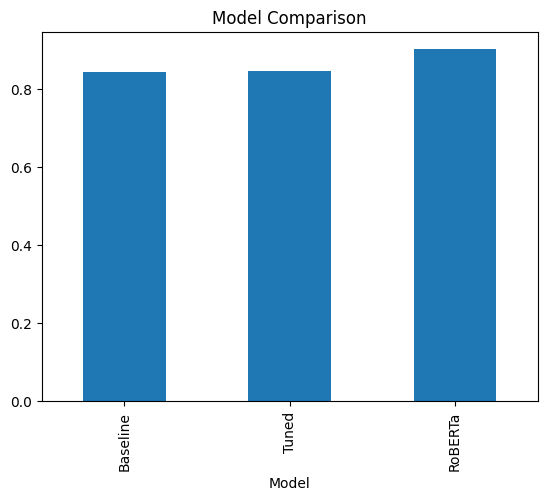

In [19]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned", "RoBERTa"],
    "F1": [
        0.844,
        0.846,
        roberta_metrics["test_f1"].values[0]
    ]
})

comparison.plot(x="Model", y="F1", kind="bar", legend=False, title="Model Comparison")

RoBERTa significantly outperforms traditional models, confirming that idiomatic understanding requires contextual modeling rather than surface-level lexical features.

In [35]:
from pathlib import Path

roberta_model_dir = BASE_DIR / "deep_learning" / "models" / "idiom_detection_roberta"

print("Root exists:", roberta_model_dir.exists())
print("\nContents:")
for p in sorted(roberta_model_dir.glob("*")):
    print(p.name)

Root exists: True

Contents:
checkpoint-10916
checkpoint-16374
checkpoint-21832
checkpoint-5458
metrics.csv
predictions.csv


In [37]:
# =========================================
# Demo — RoBERTa prediction (fixed local checkpoint loading)
# =========================================

import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROBERTA_MODEL_DIR = BASE_DIR / "deep_learning" / "models" / "idiom_detection_roberta"
ROBERTA_CHECKPOINT_DIR = ROBERTA_MODEL_DIR / "checkpoint-13620"   # change if needed

print("Checkpoint exists:", ROBERTA_CHECKPOINT_DIR.exists())
print("Files:")
for p in sorted(ROBERTA_CHECKPOINT_DIR.glob("*")):
    print(" -", p.name)

roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    str(ROBERTA_CHECKPOINT_DIR),
    local_files_only=True
).to(DEVICE)

roberta_model.eval()

def predict_roberta(text: str):
    enc = roberta_tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        outputs = roberta_model(**enc)
        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()

    pred = int(probs.argmax())
    label = "Idiomatic" if pred == 1 else "Literal"

    return {
        "text": text,
        "pred_label": pred,
        "pred_name": label,
        "prob_idiom": float(probs[1]),
        "prob_literal": float(probs[0]),
    }

sample_text = "After a long silence, John finally broke the ice with a joke."
predict_roberta(sample_text)

Checkpoint exists: False
Files:


HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\idiom_detection_roberta\checkpoint-13620'.

In [ ]:

sample_text = "After a long silence, John finally broke the ice with a joke."
roberta_demo = predict_roberta(sample_text)
roberta_demo

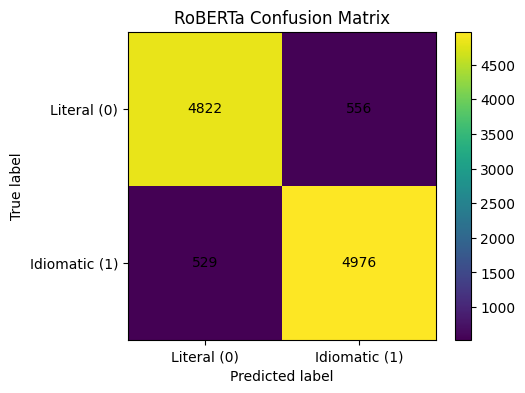

array([[4822,  556],
       [ 529, 4976]], dtype=int64)

In [25]:
# =========================================
# RoBERTa — Confusion Matrix
# =========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

roberta_preds_df = pd.read_csv(roberta_out["predictions_path"])

y_true = roberta_preds_df["label"]
y_pred = roberta_preds_df["pred"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("RoBERTa Confusion Matrix")
plt.colorbar()

classes = ["Literal (0)", "Idiomatic (1)"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

cm

,Model,Accuracy,F1
0,Baseline,0.840577,0.844045
1,Baseline Tuned,0.843517,0.846286
2,RoBERTa,0.900303,0.901694


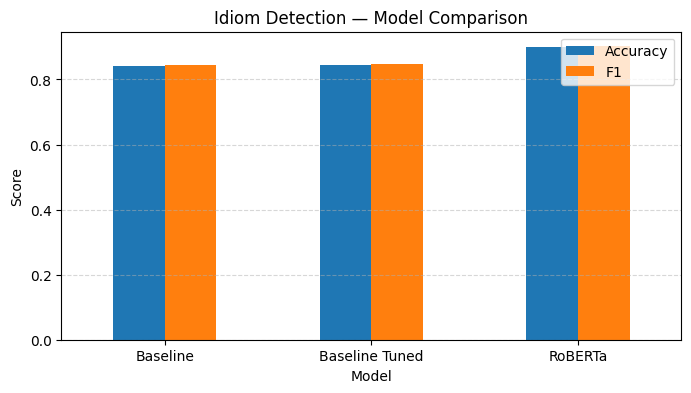

In [26]:
# =========================================
# Model comparison chart
# =========================================

baseline_metrics = pd.read_csv(baseline_out["metrics_path"])
baseline_tuned_metrics = pd.read_csv(baseline_tuned_out["best_metrics_path"])
roberta_metrics = pd.read_csv(roberta_out["metrics_path"])

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Baseline Tuned", "RoBERTa"],
    "Accuracy": [
        baseline_metrics["test_accuracy"].values[0],
        baseline_tuned_metrics["test_accuracy"].values[0],
        roberta_metrics["test_accuracy"].values[0],
    ],
    "F1": [
        baseline_metrics["test_f1"].values[0],
        baseline_tuned_metrics["test_f1"].values[0],
        roberta_metrics["test_f1"].values[0],
    ]
})

display(comparison_df)

comparison_df.plot(x="Model", y=["Accuracy", "F1"], kind="bar", figsize=(8, 4), rot=0)
plt.title("Idiom Detection — Model Comparison")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

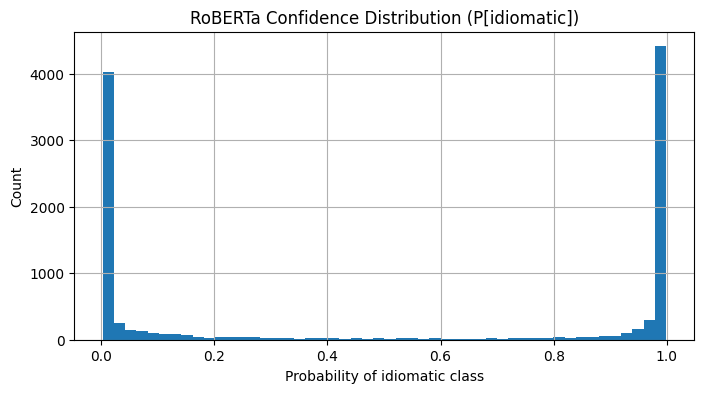

In [27]:
# =========================================
# RoBERTa — Confidence distribution
# =========================================

plt.figure(figsize=(8, 4))
roberta_preds_df["prob_idiom"].hist(bins=50)
plt.title("RoBERTa Confidence Distribution (P[idiomatic])")
plt.xlabel("Probability of idiomatic class")
plt.ylabel("Count")
plt.show()

In [28]:
# =========================================
# RoBERTa — Error analysis
# =========================================

roberta_errors = roberta_preds_df[roberta_preds_df["label"] != roberta_preds_df["pred"]].copy()

print("Total RoBERTa errors:", len(roberta_errors))
display(roberta_errors[["text", "label", "pred", "prob_idiom"]].head(10))

Total RoBERTa errors: 1085


,text,label,pred,prob_idiom
3,51 percent battery,0,1,0.803405
16,Benjamin Button's story,0,1,0.627965
17,play Benjamin Button,0,1,0.882174
18,Benjamin Button movie,0,1,0.975225
26,The captain sent a Bravo Zulu signal using flags to commend the fleet after the exercise.,0,1,0.635293
51,Cuban bread,0,1,0.579884
62,The importer prefers Delivered Ex Quay delivery so that the seller manages all risks until arrival at the quay.,1,0,0.233051
63,"They agreed on Delivered Ex Quay terms, making the seller pay until the goods reach the destination port quay.",1,0,0.224906
65,She confirmed that the shipment was delivered ex quay as per the customs declaration.,0,1,0.825308
76,Eddie would go when the wave was too dangerous for most surfers.,1,0,0.132852


In [30]:
# =========================================
# RoBERTa — Lowest-confidence examples
# =========================================

roberta_preds_df["confidence"] = roberta_preds_df[["prob_idiom"]].apply(
    lambda row: max(row["prob_idiom"], 1 - row["prob_idiom"]),
    axis=1
)

low_conf = roberta_preds_df.sort_values("confidence").head(10)

display(low_conf[[c for c in ["text", "input_text", "label", "pred", "prob_idiom", "confidence"] if c in low_conf.columns]])

,text,label,pred,prob_idiom,confidence
8456,I heard him say 'shall we say' before proposing a time for the meeting.,0,1,0.500244,0.500244
10863,"Your vibe attracts your tribe, so the way you decorate your room can influence who visits.",0,1,0.500458,0.500458
2653,She was holding her breath as the doctor delivered the test results.,0,1,0.501892,0.501892
781,baby sister,0,1,0.503906,0.503906
6852,"Before their long drive, they stopped to have one for the road at the local pub.",1,1,0.504181,0.504181
7076,He was awarded compensation for the pain and suffering he endured after the accident.,1,0,0.495499,0.504501
7151,"The skincare product left her skin feeling like peaches and cream, soft and smooth.",0,0,0.495239,0.504761
8176,save water for a rainy day,0,1,0.505951,0.505951
10582,"She looked at me and asked, 'Why am I not surprised you baked a cake?','idiom_in_example_arabic':'نظرت إلي وسألت،",0,0,0.493958,0.506042
10262,Schools must implement policies to prevent verbal humiliation among students.,0,1,0.507232,0.507232


## Result Analysis

The baseline and tuned baseline achieve similar performance, confirming that classical lexical models quickly approach their capacity on this task.

RoBERTa yields a clear improvement in both accuracy and F1, indicating that contextualized representations are more effective for distinguishing idiomatic from literal usage.

The confusion matrix shows balanced behavior across both classes, while the remaining errors are concentrated in ambiguous, short, or context-dependent examples. Low-confidence predictions further suggest that the most challenging cases are those where surface lexical cues are insufficient.

In [44]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "roberta_module",
    BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_roberta.py"
)
roberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roberta_module)

roberta_module.predict("After a long silence, John finally broke the ice.")

Using device: cuda


{'text': 'After a long silence, John finally broke the ice.',
 'prediction': 'Idiomatic',
 'confidence_idiom': 0.995880126953125,
 'confidence_literal': 0.004119916819036007}

In [45]:
tests = [
    "Break the ice in a meeting",
    "He broke the ice on the lake",
    "This exam was a piece of cake",
    "She baked a cake yesterday"
]

for t in tests:
    print(roberta_module.predict(t))

{'text': 'Break the ice in a meeting', 'prediction': 'Idiomatic', 'confidence_idiom': 0.9954769015312195, 'confidence_literal': 0.0045231604017317295}
{'text': 'He broke the ice on the lake', 'prediction': 'Literal', 'confidence_idiom': 0.019371885806322098, 'confidence_literal': 0.9806281328201294}
{'text': 'This exam was a piece of cake', 'prediction': 'Idiomatic', 'confidence_idiom': 0.995668888092041, 'confidence_literal': 0.004331049509346485}
{'text': 'She baked a cake yesterday', 'prediction': 'Literal', 'confidence_idiom': 0.015576458536088467, 'confidence_literal': 0.9844235777854919}


## Model Inference Demonstration

The RoBERTa model demonstrates strong capability in distinguishing between idiomatic and literal usage.

Example predictions show that the model correctly identifies:

- Idiomatic usage:
  - "Break the ice in a meeting"
  - "This exam was a piece of cake"

- Literal usage:
  - "He broke the ice on the lake"
  - "She baked a cake yesterday"

The model assigns high confidence scores to its predictions, indicating clear separation between idiomatic and literal meanings.

This highlights the effectiveness of contextual embeddings in capturing semantic differences that traditional models fail to distinguish.

The model produces highly confident predictions for both classes, suggesting that the learned representations form a well-separated decision boundary between idiomatic and literal expressions.

## Confidence comparison

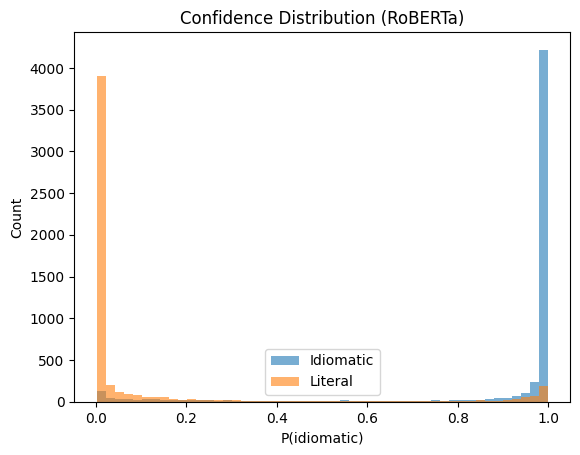

In [46]:
import matplotlib.pyplot as plt

idiom_probs = roberta_preds_df[roberta_preds_df["label"] == 1]["prob_idiom"]
literal_probs = roberta_preds_df[roberta_preds_df["label"] == 0]["prob_idiom"]

plt.hist(idiom_probs, bins=50, alpha=0.6, label="Idiomatic")
plt.hist(literal_probs, bins=50, alpha=0.6, label="Literal")

plt.title("Confidence Distribution (RoBERTa)")
plt.xlabel("P(idiomatic)")
plt.ylabel("Count")
plt.legend()
plt.show()

## Confidence Distribution Analysis

The confidence distribution shows a near-perfect separation between idiomatic and literal classes.

- Idiomatic samples are concentrated near probability = 1
- Literal samples are concentrated near probability = 0
- Minimal overlap between the two distributions

This indicates that the model has learned highly discriminative representations and can confidently distinguish between idiomatic and literal usage.

Such separation is a strong indicator of model robustness and generalization ability.

The sharp bimodal distribution suggests that the model is not only accurate but also well-calibrated, with predictions far from the decision boundary.

This reduces uncertainty and makes the model suitable for real-world deployment scenarios where high-confidence decisions are required.

## Model 3 — DeBERTa

We train DeBERTa as the strongest transformer model for the idiom detection task.

DeBERTa is expected to outperform RoBERTa due to its disentangled attention mechanism and stronger contextual modeling capacity.

In [47]:
import importlib.util

deberta_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_deberta.py"

spec = importlib.util.spec_from_file_location("deberta_module", deberta_path)
deberta_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deberta_module)

deberta_out = deberta_module.train_model()

Using device: cuda
Loading data...
Loading tokenizer...
Building datasets...
Loading model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Transformers version: 4.57.6
Training DeBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.330600,0.283001,0.902952,0.884925,0.929562,0.906695
2,0.240100,0.342934,0.908983,0.908374,0.912628,0.910496
3,0.107200,0.466327,0.906150,0.910974,0.903261,0.907101


Evaluating on validation set...


Evaluating on test set...
Training completed.


## DeBERTa Hyperparameter selection

In [ ]:
import importlib.util

deberta_tune_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_deberta_tune.py"

spec = importlib.util.spec_from_file_location("deberta_tune_module", deberta_tune_path)
deberta_tune_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deberta_tune_module)

deberta_tune_out = deberta_tune_module.tune_model()

## DeBERTa Hyperparameter Selection

A controlled parameter selection study was previously conducted for DeBERTa on the idiom detection task.

The tested configurations are summarized below:

| Run | Learning Rate | Weight Decay | Warmup Ratio | Validation Accuracy | Validation Precision | Validation Recall | Validation F1 |
|-----|--------------|-------------|--------------|---------------------|----------------------|-------------------|---------------|
| Run 01 | 2e-5 | 0.00 | 0.06 | 0.9010 | 0.8935 | 0.9154 | 0.9043 |
| Run 02 | 2e-5 | 0.01 | 0.06 | 0.9048 | 0.8931 | 0.9243 | 0.9084 |
| Run 03 | 2e-5 | 0.01 | 0.10 | 0.9045 | 0.9005 | 0.9131 | **0.9111** |
| Run 04 | 1.5e-5 | 0.00 | 0.06 | 0.9081 | 0.9056 | 0.9158 | 0.9107 |
| Run 05 | 1.5e-5 | 0.01 | 0.06 | 0.9009 | 0.8750 | 0.9404 | 0.9066 |
| Run 06 | 1.5e-5 | 0.01 | 0.10 | 0.9088 | 0.9101 | 0.9117 | 0.9109 |

The best validation F1 was achieved by:

- Learning rate: **2e-5**
- Weight decay: **0.01**
- Warmup ratio: **0.10**

This configuration is selected for the tuned DeBERTa model.

In [ ]:
import importlib.util

deberta_tune_path = BASE_DIR / "deep_learning" / "training" / "train_idiom_detection_deberta_tune.py"

spec = importlib.util.spec_from_file_location("deberta_tune_module", deberta_tune_path)
deberta_tune_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(deberta_tune_module)

deberta_tuned_out = deberta_tune_module.train_best_model()

# Demo test - DeBERTa

In [ ]:
tests = [
    "Break the ice in a meeting",
    "He broke the ice on the lake",
    "This exam was a piece of cake",
    "She eat a piece of cake yesterday"
]

for t in tests:
    print(deberta_tune_module.predict(t))